## Setup

In [67]:
import pandas as pd
import os
import json
import ast
import copy
import re
import torch
import numpy as np
import chromadb
import time
import concurrent.futures

from openai import RateLimitError
from tqdm.notebook import tqdm
from chromadb.utils import embedding_functions
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from sentence_transformers import SentenceTransformer
from pathlib import Path
from datasets import load_dataset
from openai import OpenAI
from dotenv import load_dotenv

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

In [68]:
load_dotenv()

MAX_WORKERS = 8
WAIT_TIME = 60
RANDOM_SEED = 42
BUFFER_SIZE = 10_000
SAMPLE_SIZE = 100
MODEL_ID = "nvidia/nemotron-3-super-120b-a12b:free"
EMBEDDING_MODEL_ID = "sentence-transformers/all-mpnet-base-v2"
EMBEDDING_BATCH_SIZE = 256

DATA_PATH = Path("./data")
INPUT_DATA_DIR = DATA_PATH / "input"
RAW_1P_DATA_PATH = INPUT_DATA_DIR / "aei_raw_1p_api_2026-02-05_to_2026-02-12.csv"
RAW_CLAUDE_DATA_PATH = INPUT_DATA_DIR / "aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv"
TASK_STATEMENTS_PATH = INPUT_DATA_DIR / "TaskStatements.csv"
PATENTS_DATA_PATH = INPUT_DATA_DIR / "patent_task_matches_percentile.csv"

PROMPTS_DIR = Path("./prompts")
WORK_RELATED_PROMPT_PATH = PROMPTS_DIR / "work_related.json"
TASK_MAPPING_PROMPT_PATH = PROMPTS_DIR / "task_mapping.json"
AUTOMATION_AUGMENTATION_PROMPT_PATH = PROMPTS_DIR / "automation_augmentation.json"
PATENTS_PROMPT_PATH = PROMPTS_DIR / "patents.json"

CHROMA_DB_PATH = DATA_PATH / "chroma"
CLUSTERS_COLLECTION_NAME = "clusters"

OUTPUT_DIR = DATA_PATH / "output"
WORK_RELATED_OUTPUT_PATH = OUTPUT_DIR / f"work_related_{SAMPLE_SIZE}.csv"
HIERARCHY_OUTPUT_PATH = OUTPUT_DIR / "hierarchy.csv"
TASK_MAPPING_OUTPUT_PATH = OUTPUT_DIR / f"task_mapping_{SAMPLE_SIZE}.csv"
AUTOMATION_AUGMENTATION_OUTPUT_PATH = OUTPUT_DIR / f"automation_augmentation_{SAMPLE_SIZE}.csv"
PATENTS_OUTPUT_PATH = OUTPUT_DIR / f"patents_{SAMPLE_SIZE}.csv"
WILDCHAT_DATASET = "allenai/WildChat-4.8M"
WILDCHAT_SAMPLES_FILE = INPUT_DATA_DIR / f"WildChat-4.8M-sample-{SAMPLE_SIZE}.csv"
CONVERSATION_FIELD = "conversation"
LANGUAGE_FIELD = "language"
TARGET_LANGUAGE = "English"

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"


PARENT_COLUMN = "parent_id"
COUNT_VARIABLE = "onet_task_count"

In [69]:
device = ""

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [70]:
model = SentenceTransformer(EMBEDDING_MODEL_ID).to(device=device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
client = OpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
)

In [72]:
chroma = chromadb.PersistentClient(path=CHROMA_DB_PATH)

## Conversation-task mapping
In order to map conversations to tasks, we are using the following steps:

1. Retrieve the conversations from Wildchat, sampling for English conversations 
2. Filter out all the non-work-related conversations
3. Retrieve the task hierarchy from the Anthropic's dataset
4. Map through the hierarchy

In [73]:
def strip_messages(msgs: list[dict[str, str]]) -> list[dict[str, str]]:
    """
    Starting from WildChat conversations, strip all fields that are not "role" and "content" to be able to feed them to the model.

    :param msgs: list of messages in the original format
    :return: list of messages in the stripped format
    """
    return [{"role": m["role"], "content": m["content"]} for m in msgs]

In [74]:
def format_tasks(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """
    Takes a DataFrame and formats the task names in the specified column by stripping whitespace, converting to lowercase and removing punctuation.

    :param df: DataFrame containing the tasks to format, with a column "task" for the task names
    :param column_name: name of the column containing the task names to format
    :return: DataFrame with the task names in the specified column formatted
    """
    df[column_name] = df[column_name].str.strip().str.lower().str.replace(r'[^\w\s]', '', regex=True)
    return df

In [75]:
if not WILDCHAT_SAMPLES_FILE.exists():
    wildchat_ds = load_dataset(
        path=WILDCHAT_DATASET,
        split="train",
        streaming=True
    )
    english_conversations_rows = wildchat_ds.filter(lambda x: x[LANGUAGE_FIELD] == TARGET_LANGUAGE)
    sample_conversations_rows = pd.DataFrame(english_conversations_rows.shuffle(
        seed=RANDOM_SEED,
        buffer_size=BUFFER_SIZE
    ).take(SAMPLE_SIZE))
    sample_conversations = sample_conversations_rows[[CONVERSATION_FIELD]].copy()
    sample_conversations[CONVERSATION_FIELD] = sample_conversations[CONVERSATION_FIELD].apply(strip_messages)
    sample_conversations.to_csv(
        path_or_buf=WILDCHAT_SAMPLES_FILE,
        columns=["conversation"],
    )
else:
    sample_conversations = pd.read_csv(filepath_or_buffer=WILDCHAT_SAMPLES_FILE)
    sample_conversations["conversation"] = sample_conversations["conversation"].apply(ast.literal_eval)
sample_conversations.head(1)

,Unnamed: 0,conversation
0,0,"[{'role': 'user', 'content': 'i own a rusty 1975 plymouth fury beater. the body is rusty, the engine makes a rattling noise and the exhaust has a bad backfire.'}, {'role': 'assistant', 'content': 'Despite its flaws, my 1975 Plymouth Fury holds a special place in my heart. It may not be the most reliable or attractive car on the road, but it has character and a sense of nostalgia that is hard to replicate. The rust on the body is a testament to its age and history. The car has been through a lot and has seen many miles. While it may not look pretty, the rust adds a certain charm to the car, making it stand out from the rest of the shiny, new vehicles on the road. The rattling noise from the engine is a constant reminder that the car is not perfect, but it still runs. Every time I turn the key and hear that distinctive sound, I am filled with a sense of satisfaction and pride. I know that this car has a lot of life left in it, and I am determined to keep it running for as long as possible. The backfire from the exhaust is just another quirk that adds to the car's personality. It may be loud and obnoxious, but it also lets everyone know that this car is not to be underestimated. Overall, my 1975 Plymouth Fury may not be the most practical or reliable car, but it holds a special place in my heart. It has character, charm, and a sense of history that cannot be replicated. Despite its flaws, I wouldn't trade it for anything.'}]"


In [76]:
def get_gpt_response(messages: list[dict[str, str]], max_retries: int = 5) -> str:
    """
    Get a response from the GPT model, extracting the content inside <answer> tags if present.

    :param messages: list of messages to send to the model
    :param max_retries: maximum number of retries in case of rate limiting
    :return: the model's response
    """
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_ID,
                messages=messages,
            )
            content = response.choices[0].message.content
            if content is None:
                print(f"Warning: received null content from API (attempt {attempt + 1})")
                return ""
            dirty_result = content.strip()
            cleaned_result = re.search(r'<answer>(.*?)</answer>', dirty_result, re.DOTALL)
            if cleaned_result:
                return cleaned_result.group(1)
            return ""
        except RateLimitError as e:
            wait = WAIT_TIME ** attempt
            print(f"Rate limited (429). Waiting {wait}s before retry {attempt + 1}/{max_retries}...")
            time.sleep(wait)
    print(f"Failed after {max_retries} retries.")
    return ""


In [77]:
def get_messages(path: Path) -> list[dict[str, str]]:
    """
    Retrieve messages from a given file path.
    """
    with open(path, "r") as f:
        return json.load(f)

In [78]:
def format_conversation(conversation: list[dict[str, str]]) -> str:
    """
    Format a conversation (list of messages) into a string format suitable for prompting the model.

    :param conversation: list of messages in the conversation
    :return: formatted conversation as a string
    """
    formatted = ""
    for message in conversation:
        role = message["role"]
        content = message["content"]
        formatted += f"{role}: {content}\n"
    return formatted

In [79]:
def build_messages(template: list[dict[str, str]], **kwargs):
    """
    Build a list of messages by replacing placeholders in the template with actual values.

    :param template: list of messages with placeholders in the "content" field
    :param kwargs: key-value pairs where key is the placeholder name and value is the value to replace it with
    :return: list of messages with placeholders replaced
    """
    msgs = copy.deepcopy(template)
    for msg in msgs:
        for key, value in kwargs.items():
            if "{" + key + "}" in msg["content"]:
                msg["content"] = msg["content"].replace("{" + key + "}", value)
    return msgs

In [80]:
def parallelize_work_filtering(messages: list[dict[str, str]]) -> str:
    """
    Helper function to parallelize the work filtering process by allowing the get_gpt_response function to be called in parallel.

    :param messages: list of messages to send to the model
    :return: the model's response
    """
    return get_gpt_response(messages=messages)

def filter_work_conversations(conversations: pd.DataFrame) -> pd.DataFrame:
    """
    Filter conversations to determine which ones are work-related using the GPT model.

    :param conversations: DataFrame containing conversations to filter
    :return: DataFrame containing conversations with an additional column "is_work_related" indicating whether the conversation is work-related or not
    """
    formatted_messages = []
    result = pd.DataFrame()
    template = get_messages(WORK_RELATED_PROMPT_PATH)
    for index, row in conversations.iterrows():
        raw_conversation = row["conversation"]
        conversation = format_conversation(conversation=raw_conversation)
        messages = build_messages(template=template, conversation=conversation)
        record = {"conversation": conversation, "messages": messages}
        formatted_messages.append(record)
    
    records = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(parallelize_work_filtering, entry["messages"]): entry["conversation"] 
            for entry in formatted_messages
        }

        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            conversation = futures[future]
            try:
                response = future.result()
                record = {"conversation": conversation, "is_work_related": response}
                records.append(record)
            except Exception as e:
                print(f"Error processing conversation: {e}")
    
    result = pd.DataFrame(records)
    return result

In [81]:
if not WORK_RELATED_OUTPUT_PATH.exists():
    work_related_conversations_df = filter_work_conversations(conversations=sample_conversations)
    work_related_conversations_df.to_csv(WORK_RELATED_OUTPUT_PATH)
else:
    work_related_conversations_df = pd.read_csv(WORK_RELATED_OUTPUT_PATH)
    work_related_conversations_df = work_related_conversations_df[work_related_conversations_df["is_work_related"] == "Yes"]
work_related_conversations_df.head(1)

,Unnamed: 0,conversation,is_work_related
1,1,"user: Make the first part of the Delta Systems history, I made the table’s first 2 parts\n“Progressbar Compass” Era:\nProgressbar Compass was released in 1999, with codename 98_compass (Internal). First part of the project, a heavy-modified Progressbar 98 SE.\nProgressbar Compass: Revision 2 was made in 2004, with codename dt_compass (Internal). Second part of the project.\nAlso a Wiki code that I used to make:\n=== Progressbar Compass ===\nTBA.\n\n=== Project Compass Development ===\nSome years later, it was speculated that a new system would appear in the market. An ex-employee of an unknown company revealed this system to 3 people, it is called “Project Compass”, the employee, whose name is Jacob Thompson, confirmed that the reason for this Beta code was because the system would be very easy to handle, and with few applications.\nUsing the table's parts, make the thing from the Project Compass Development\nassistant: era:\nIn response to the buzz around the rumored ""Project Compass"", Delta Systems began development on their own version of the system. In 2005, they announced the start of ""Project Compass Development"" with the goal of creating a user-friendly and efficient operating system with a sleek design. Delta Systems hired Jacob Thompson, the ex-employee who leaked information about the original ""Project Compass"", to consult on the project. The internal codename for this project was ""delta_compass"". The development process lasted for several years, with multiple revisions and updates. Delta Systems aimed to release the final version of the operating system in 2010.\n",Yes


In [82]:
raw_1p_api_df = pd.read_csv(RAW_1P_DATA_PATH)
raw_claude_api_df = pd.read_csv(RAW_CLAUDE_DATA_PATH)

In [83]:
raw_claude_api_df.head()

,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,directive,15.000000
1,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,directive,20.270270
2,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,learning,20.000000
3,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,learning,27.027027
4,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,not_classified,16.000000


In [84]:
filtered_df = raw_claude_api_df[
    ((raw_claude_api_df["level"] == 0) & (raw_claude_api_df["facet"] == "onet_task")) |
    (raw_claude_api_df["level"].isin([1, 2]))
].copy()
filtered_df["cluster_name"] = filtered_df["cluster_name"].str.split("::").str[0]
columns_to_keep = ["level", "cluster_name"]
clusters_df = (
    filtered_df[columns_to_keep]
   .drop_duplicates()
   .reset_index(drop=True)
   .iloc[50:]
)

clusters_df.reset_index(inplace=True, drop=True)
display(clusters_df.head())

,level,cluster_name
0,0,"use computers for various applications, such as database management or word processing."
1,0,"write advertising copy for use by publication, broadcast, or internet media to promote the sale of goods and services."
2,0,"write interesting and effective press releases, prepare information for media kits, and develop and maintain company internet or intranet web pages."
3,0,"write new programs or modify existing programs to meet customer requirements, using current programming languages and technologies."
4,0,"write original or adapted material for dramas, comedies, puppet shows, narration, or other performances."


In [85]:
collection = chroma.get_or_create_collection(
    name=CLUSTERS_COLLECTION_NAME,
    embedding_function=embedding_functions.SentenceTransformerEmbeddingFunction(model_name=EMBEDDING_MODEL_ID),
    metadata={"hnsw:space": "cosine"},
)

if collection.count() == 0:
    embeddings = model.encode(
        clusters_df["cluster_name"].to_list(),
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    collection.add(
        ids=clusters_df.index.astype(str).tolist(),
        embeddings=embeddings,
        metadatas=clusters_df[["level", "cluster_name"]].to_dict(orient="records"),
    )
else:
    response = collection.get(
        ids=clusters_df.index.astype(str).tolist(),
        include=["embeddings"],
    )
    embeddings_map = {
        int(id): emb
        for id, emb in zip(response["ids"], response["embeddings"])
    }
    embeddings = [embeddings_map[idx] for idx in clusters_df.index]

clusters_df["embedding"] = list(embeddings)
clusters_df["id"] = clusters_df.index

In [86]:
clusters_df.head(1)

,level,cluster_name,embedding,id
0,0,"use computers for various applications, such as database management or word processing.","[0.009728441946208477, 0.025367509573698044, -0.016061507165431976, -0.00128194410353899, 0.027507131919264793, 0.019861362874507904, 0.09170021116733551, 0.03568260744214058, 0.035968322306871414, 0.018364625051617622, -0.04178381338715553, -0.03396006301045418, 0.03770158812403679, -0.0009839646518230438, 0.02416253462433815, -0.06573130190372467, 0.07283139228820801, 0.012364130467176437, -0.0259933453053236, 0.018403254449367523, -0.04371950775384903, -0.015318568795919418, -0.01616808958351612, 0.05107581615447998, -0.024717487394809723, -0.05619335174560547, 0.0048100026324391365, -0.0023542994167655706, 0.006202411837875843, 0.04801786690950394, 0.05510546639561653, -0.03123081848025322, 0.03357374668121338, -0.014386367052793503, 1.326925143985136e-06, 0.018716908991336823, -0.02587188594043255, -0.016429103910923004, -0.025957608595490456, 0.010094698518514633, 0.09713298827409744, 0.03728724271059036, 0.03141466900706291, 0.01911819353699684, 0.009474482387304306, -0.03111899457871914, 0.02938159555196762, -0.02297491393983364, -0.042561762034893036, 0.03485485911369324, -0.03326563537120819, 0.02865876816213131, -0.05216776207089424, -0.05412650108337402, -0.047356199473142624, -0.004871001932770014, 0.024947701022028923, 0.029283948242664337, 0.08052533864974976, -0.018679367378354073, 0.02426285855472088, -0.055602315813302994, -0.031077368184924126, -0.016721604391932487, 0.06661185622215271, 0.05136730894446373, 0.056868236511945724, -0.05172422155737877, -0.0004238967376295477, -0.021480321884155273, 0.010536623187363148, 0.02811611071228981, 0.016689421609044075, 0.012476497329771519, -0.012547905556857586, 0.02303696610033512, -0.03043767437338829, 0.0009173701400868595, -0.024347100406885147, -0.021836580708622932, 0.02079739421606064, 0.04702109098434448, 0.0017110859043896198, -0.001924994052387774, 0.08819139748811722, -0.013484040275216103, -0.003787948051467538, 0.01901501975953579, -0.012390214949846268, 0.023359457030892372, 0.026170510798692703, 0.024865763261914253, 0.04773973301053047, -0.011323672719299793, -0.045296501368284225, -0.027770914137363434, -0.024057086557149887, 0.01017090305685997, -0.008862943388521671, -0.017053205519914627, ...]",0


In [87]:
level_0 = clusters_df[clusters_df["level"] == 0].copy()
level_1 = clusters_df[clusters_df["level"] == 1].copy()
level_2 = clusters_df[clusters_df["level"] == 2].copy()

level_2[PARENT_COLUMN] = None

In [88]:
def assign_parents(parents: pd.DataFrame, children: pd.DataFrame):
    """
    Assign a parent to each child based on the highest cosine similarity between their embeddings.

    :param parents: DataFrame containing parent clusters with their embeddings
    :param children: DataFrame containing child clusters with their embeddings and a column for the parent to be assigned
    :return: the children DataFrame with the parent column filled with the id of the most similar parent for each child
    """
    children_matrix = np.stack(children["embedding"])
    parent_matrix = np.stack(parents["embedding"])
    similarity_matrix = cosine_similarity(children_matrix, parent_matrix)
    most_similar_parent_indices = similarity_matrix.argmax(axis=1)
    children[PARENT_COLUMN] = parents["id"].iloc[most_similar_parent_indices].values
    return children

In [89]:
level_0 = assign_parents(parents=level_1, children=level_0)
level_1 = assign_parents(parents=level_2, children=level_1)
hierarchy_df = pd.concat([level_0, level_1, level_2], ignore_index=True)
hierarchy_df.drop(columns=["embedding"], inplace=True)
hierarchy_df.to_csv(HIERARCHY_OUTPUT_PATH, index=False)
hierarchy_df.head()

,level,cluster_name,id,parent_id
0,0,"use computers for various applications, such as database management or word processing.",0,71
1,0,"write advertising copy for use by publication, broadcast, or internet media to promote the sale of goods and services.",1,28
2,0,"write interesting and effective press releases, prepare information for media kits, and develop and maintain company internet or intranet web pages.",2,67
3,0,"write new programs or modify existing programs to meet customer requirements, using current programming languages and technologies.",3,39
4,0,"write original or adapted material for dramas, comedies, puppet shows, narration, or other performances.",4,11


In [90]:
def get_task_id(task_name: str, hierarchy: pd.DataFrame) -> int:
    """
    Get the ID of a task based on its name and the hierarchy DataFrame.

    :param task_name: Name of the task to find
    :param hierarchy: DataFrame containing the hierarchy of tasks
    :return: ID of the task if found, otherwise None
    """
    record = hierarchy[hierarchy["cluster_name"] == task_name]
    if not record.empty:
        return record["id"].values[0]
    return None

In [91]:
def format_options(tasks: pd.DataFrame) -> str:
    """
    Format a list of tasks into a string format suitable for prompting the model, where each task is listed on a new line.

    :param tasks: DataFrame containing the tasks to format, with a column "cluster_name" for the task names
    :return: formatted string with each task name on a new line
    """
    options_str = ""
    for _, row in tasks.iterrows():
        option_name = row["cluster_name"]
        options_str += f"{option_name}\n"
    return options_str

In [92]:
def map_conversation_to_task(conversations: pd.DataFrame, tasks: pd.DataFrame) -> pd.DataFrame:
    """
    Map each conversation to a task in the hierarchy by prompting the model to choose the most appropriate task at each level of the hierarchy, starting from the highest level (level 2) down to the lowest level (level 0).

    :param conversations: DataFrame containing the conversations to map, with a column "conversation" for the conversation text
    :param tasks: DataFrame containing the hierarchy of tasks, with columns "id", "level", "cluster_name", and "parent_id"
    :return: DataFrame containing the original conversation and the corresponding task at each level of the hierarchy (columns "level_2_task", "level_1_task", "level_0_task")
    """
    template = get_messages(path=TASK_MAPPING_PROMPT_PATH)
    result = pd.DataFrame(columns=["conversation", "level_2_task", "level_1_task", "level_0_task"])

    for index, row in tqdm(conversations.iterrows(), total=conversations.shape[0]):
        conversation = row["conversation"]
        record = {"conversation": conversation, "level_2_task": None, "level_1_task": None, "level_0_task": None}

        high_level_tasks = tasks[tasks["level"] == 2]
        options_str = format_options(tasks=high_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_2_response = get_gpt_response(messages=messages).strip()
        record["level_2_task"] = level_2_response

        parent_id = get_task_id(task_name=level_2_response, hierarchy=tasks)
        medium_level_tasks = tasks[(tasks["level"] == 1) & (tasks["parent_id"] == parent_id)]
        options_str = format_options(tasks=medium_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_1_response = get_gpt_response(messages=messages).strip()
        record["level_1_task"] = level_1_response

        parent_id = get_task_id(task_name=level_1_response, hierarchy=tasks)
        low_level_tasks = tasks[(tasks["level"] == 0) & (tasks["parent_id"] == parent_id)]
        options_str = format_options(tasks=low_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_0_response = get_gpt_response(messages=messages).strip()
        record["level_0_task"] = level_0_response

        result = pd.concat([result, pd.DataFrame([record])], ignore_index=True)

    return result

In [93]:
if not TASK_MAPPING_OUTPUT_PATH.exists():
    mapped_conversations_df = map_conversation_to_task(
        conversations=work_related_conversations_df,
        tasks=hierarchy_df
    )
    mapped_conversations_df = format_tasks(df=mapped_conversations_df, column_name="level_0_task")
    mapped_conversations_df.to_csv(TASK_MAPPING_OUTPUT_PATH, index=False)
else:
    mapped_conversations_df = pd.read_csv(TASK_MAPPING_OUTPUT_PATH)
mapped_conversations_df.head(1)

  0%|          | 0/69 [00:00<?, ?it/s]

,conversation,level_2_task,level_1_task,level_0_task
0,"user: Make the first part of the Delta Systems history, I made the table’s first 2 parts\n“Progressbar Compass” Era:\nProgressbar Compass was released in 1999, with codename 98_compass (Internal). First part of the project, a heavy-modified Progressbar 98 SE.\nProgressbar Compass: Revision 2 was made in 2004, with codename dt_compass (Internal). Second part of the project.\nAlso a Wiki code that I used to make:\n=== Progressbar Compass ===\nTBA.\n\n=== Project Compass Development ===\nSome years later, it was speculated that a new system would appear in the market. An ex-employee of an unknown company revealed this system to 3 people, it is called “Project Compass”, the employee, whose name is Jacob Thompson, confirmed that the reason for this Beta code was because the system would be very easy to handle, and with few applications.\nUsing the table's parts, make the thing from the Project Compass Development\nassistant: era:\nIn response to the buzz around the rumored ""Project Compass"", Delta Systems began development on their own version of the system. In 2005, they announced the start of ""Project Compass Development"" with the goal of creating a user-friendly and efficient operating system with a sleek design. Delta Systems hired Jacob Thompson, the ex-employee who leaked information about the original ""Project Compass"", to consult on the project. The internal codename for this project was ""delta_compass"". The development process lasted for several years, with multiple revisions and updates. Delta Systems aimed to release the final version of the operating system in 2010.\n","Assist with creative content, marketing, and media production projects","Assist with creative fiction writing, editing, and development",write original or adapted material for dramas comedies puppet shows narration or other performances


## Automation/Augmentation
In order to check whether a task is augmented or automated, we are using the following steps:
1. Apply the rubric presented in "Eloundou et al. (2023)" to the conversations
2. Apply patent-task matches used in "Septiandri et al. (2024)" to the conversations

In [94]:
tasks_df = pd.read_csv(filepath_or_buffer=TASK_STATEMENTS_PATH)
tasks_columns_to_keep = ["O*NET-SOC Code", "Title", "Task ID", "Task"]
tasks_df = tasks_df[tasks_columns_to_keep].copy()
tasks_df = format_tasks(df=tasks_df, column_name="Task")
tasks_df.rename(str.lower, axis="columns", inplace=True)
tasks_df.rename(columns={"o*net-soc code": "onet_soc_code", "task id": "task_id"}, inplace=True)
tasks_df.head(2)

,onet_soc_code,title,task_id,task
0,11-1011.00,Chief Executives,8823,direct or coordinate an organizations financial or budget activities to fund operations maximize investments or increase efficiency
1,11-1011.00,Chief Executives,8831,appoint department heads or managers and assign or delegate responsibilities to them


In [95]:
patents_df = pd.read_csv(filepath_or_buffer=PATENTS_DATA_PATH)
patents_df = format_tasks(df=patents_df, column_name="task")
patents_columns_to_keep = ["task_id", "task", "onet_soc_code", "patent_abstract"]
patents_df = (
    patents_df[patents_columns_to_keep]
    .copy()
    .drop_duplicates(subset=["patent_abstract", "task"], keep="first")
    .reset_index(drop=True)
)
patents_df.head(2)

,task_id,task,onet_soc_code,patent_abstract
0,39,set and monitor product standards examining samples of raw products or directing testing during processing to ensure finished products are of prescribed quality,11-3051.00,"A method to be performed in a production support system configured to process a raw material and to produce a product. And the method includes: acquiring a plurality of element values relating to production elements of the product; determining whether the element values are within allowable ranges in which a quality of the product meets a predetermined allowed quality; resetting the allowable ranges of one or a plurality of other element values to the allowable ranges in which the quality of the product meets the predetermined allowed quality, upon determining that at least one element value exceeds the allowable range; and outputting information about the reset allowable ranges."
1,40,develop or implement production tracking or quality control systems analyzing production quality control maintenance or other operational reports to detect production problems,11-3051.00,"Provided is a management system for performing quality management on production equipment. A management system that includes: an acquisition component that acquires status information for production equipment that is subject to management; a detection component that, on the basis of the acquired status information, detects the occurrence of some event; and a display component that displays, separated according to inclusion in the four perspectives Machine, Man, Material, and Method, a plurality of factors that could be presumed to have caused the detected event in a manner in which the contents thereof and a probability of having caused the event can be compared."


In [96]:
# Not all the tasks in the patents dataset have a corresponding entry in the tasks dataset
enriched_patents_df = pd.merge(patents_df, tasks_df, on="task_id", how="inner", suffixes=("_patents", "_tasks"))
enriched_patents_df = enriched_patents_df[["task_id", "task_tasks", "onet_soc_code_tasks", "patent_abstract", "title"]].copy()
enriched_patents_df.rename(columns={"task_tasks": "task", "onet_soc_code_tasks": "onet_soc_code"}, inplace=True)
enriched_patents_df.head(2)

,task_id,task,onet_soc_code,patent_abstract,title
0,39,set and monitor product standards examining samples of raw products or directing testing during processing to ensure finished products are of prescribed quality,11-3051.00,"A method to be performed in a production support system configured to process a raw material and to produce a product. And the method includes: acquiring a plurality of element values relating to production elements of the product; determining whether the element values are within allowable ranges in which a quality of the product meets a predetermined allowed quality; resetting the allowable ranges of one or a plurality of other element values to the allowable ranges in which the quality of the product meets the predetermined allowed quality, upon determining that at least one element value exceeds the allowable range; and outputting information about the reset allowable ranges.",Industrial Production Managers
1,40,develop or implement production tracking or quality control systems analyzing production quality control maintenance or other operational reports to detect production problems,11-3051.00,"Provided is a management system for performing quality management on production equipment. A management system that includes: an acquisition component that acquires status information for production equipment that is subject to management; a detection component that, on the basis of the acquired status information, detects the occurrence of some event; and a display component that displays, separated according to inclusion in the four perspectives Machine, Man, Material, and Method, a plurality of factors that could be presumed to have caused the detected event in a manner in which the contents thereof and a probability of having caused the event can be compared.",Industrial Production Managers


In [ ]:
def parallelize_automation_augmentation(messages: list[dict[str, str]]) -> str:
    """
    Helper function to parallelize the automation vs augmentation checking process by allowing the get_gpt_response function to be called in parallel.

    :param messages: list of messages to send to the model
    :return: the model's response
    """
    return get_gpt_response(messages=messages)

def check_automation_augmentation(
        conversations: pd.DataFrame, 
        tasks: pd.DataFrame,
        patents: pd.DataFrame, 
        use_patents: bool
    ) -> pd.DataFrame:
    """
    Check if conversations are automated or augmented. When use_patents is False, the model is prompted to determine if the task being performed in the conversation is more likely to be automated or augmented based on the task description. When use_patents is True, the model is prompted to determine if the task being performed in the conversation is more likely to be automated or augmented based on the task description and the corresponding patent abstract.

    :param conversations: DataFrame containing the conversations to check and the corresponding task at each level of the hierarchy (columns "level_2_task", "level_1_task", "level_0_task")
    :param tasks: DataFrame containing the tasks
    :param patents: DataFrame containing the patents to check against
    :param use_patents: boolean indicating whether to use patents in the evaluation
    :return: DataFrame containing the original conversation and a column indicating if it is automated or augmented
    """
    path = PATENTS_PROMPT_PATH if use_patents else AUTOMATION_AUGMENTATION_PROMPT_PATH 
    template = get_messages(path=path)
    formatted_messages = []

    for _, row in tqdm(conversations.iterrows(), total=conversations.shape[0]):
        conversation = row["conversation"]
        level_0_task = row["level_0_task"]
        # print(f"Processing conversation with level 0 task: {level_0_task}")

        if not use_patents:
            task_record = tasks[tasks["task"] == level_0_task]
            occupation = task_record["title"].values[0] if not task_record.empty else ""
            messages = build_messages(
                template=template, 
                occupation=occupation,
                task=level_0_task,
                conversation=conversation,
            )
            record = {"conversation": conversation, "messages": messages, "task": level_0_task}
            formatted_messages.append(record)
        else:
            patent_rows = patents[patents["task"] == level_0_task]
            for _, patent_row in patent_rows.iterrows():
                occupation = patent_row["title"]
                task = patent_row["task"]
                patent_abstract = patent_row["patent_abstract"]
                messages = build_messages(
                    template=template,
                    occupation=occupation,
                    task=task,
                    conversation=conversation,
                    patent_abstract=patent_abstract, 
                )
                record = {"conversation": conversation, "messages": messages, "task": level_0_task}
                formatted_messages.append(record)

    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(parallelize_automation_augmentation, entry["messages"]): (entry["conversation"], entry["task"])
            for entry in formatted_messages
        }

        records = []
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            conversation, task = futures[future]
            try:
                label = future.result()
                record = {
                    "conversation": conversation,
                    "task": task,
                    "rubric_label": label,
                }
                records.append(record)
            except Exception as e:
                print(f"Error processing conversation: {e}")
            
    result = pd.DataFrame(records)
    return result

In [105]:
if not AUTOMATION_AUGMENTATION_OUTPUT_PATH.exists():
    automation_augmentation_df = check_automation_augmentation(
        conversations=mapped_conversations_df,
        tasks=tasks_df,
        patents=enriched_patents_df,
        use_patents=False,
    )
    automation_augmentation_df.to_csv(AUTOMATION_AUGMENTATION_OUTPUT_PATH, index=False)
else:
    automation_augmentation_df = pd.read_csv(AUTOMATION_AUGMENTATION_OUTPUT_PATH)
automation_augmentation_df.head(1)

,conversation,task,rubric_label
0,"user: How to be a good police officer \nassistant: 1. Education and Training: Obtain the necessary education and training required to become a police officer. This usually includes graduating from a police academy and potentially earning a college degree in criminal justice, psychology, or a related field.\n\n2. Communication Skills: Develop strong communication skills, both verbal and non-verbal, as they are crucial for effectively interacting with citizens, colleagues, and other professionals.\n\n3. Adhere to the Law: Always follow the laws and regulations in your jurisdiction, maintaining a high level of personal and professional integrity.\n\n4. Community Policing: Engage with your community in a positive way and build rapport with citizens to foster trust and collaboration.\n\n5. Critical Thinking and Problem Solving: Hone your critical thinking and problem-solving skills to make sound decisions in high-stress situations.\n\n6. Physical Fitness: Maintain a high level of physical fitness to perform your duties effectively and to protect yourself and the community.\n\n7. Emotional Intelligence: Cultivate your emotional intelligence by developing empathy, self-awareness, and the ability to manage stress and emotions.\n\n8. Fairness and Impartiality: Treat everyone fairly and impartially, regardless of race, ethnicity, gender, religion, or socioeconomic status.\n\n9. Continuing Education: Stay up-to-date with the latest law enforcement trends, best practices, and technologies through ongoing training and professional development.\n\n10. Teamwork: Work collaboratively with fellow officers and other first responders to ensure the safety and wellbeing of the community.\n\n11. Accountability: Accept responsibility for your actions and maintain transparency in all aspects of your job.\n\n12. Ethics and Integrity: Uphold the highest ethical standards and demonstrate integrity in all situations, both on and off duty.\n\nBy adhering to these principles and dedicating yourself to ongoing improvement, you can become a successful and respected law enforcement professional.\n",provide occupational educational and other information to individuals so that they can make educational and vocational plans,E1


In [106]:
if not PATENTS_OUTPUT_PATH.exists():
    patents_aug_aut_df = check_automation_augmentation(
        conversations=mapped_conversations_df,
        tasks=tasks_df,
        patents=enriched_patents_df,
        use_patents=True,
    )
    patents_aug_aut_df.to_csv(PATENTS_OUTPUT_PATH, index=False)
else:
    patents_aug_aut_df = pd.read_csv(PATENTS_OUTPUT_PATH)
patents_aug_aut_df.head(1)

  0%|          | 0/69 [00:00<?, ?it/s]

Processing conversation with level 0 task: write original or adapted material for dramas comedies puppet shows narration or other performances
Processing conversation with level 0 task: provide occupational educational and other information to individuals so that they can make educational and vocational plans
Processing conversation with level 0 task: provide applicants with assistance in completing application forms such as those for job referrals or unemployment compensation claims
Processing conversation with level 0 task: gather analyze or document user feedback to locate or resolve sources of problems
Processing conversation with level 0 task: review written audio or video copy and correct errors in content grammar or punctuation following prescribed editorial style and formatting guidelines
Processing conversation with level 0 task: prepare documentation or presentations including charts photos or graphs
Processing conversation with level 0 task: encourage clients to express thei

  0%|          | 0/69 [00:00<?, ?it/s]

Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 1s before retry 1/5...
Rate limited (429). Waiting 60s before retry 2/5...
Rate limited (429). Wa

,conversation,task,rubric_label
0,"user: PacD Custom Form for Packaging Confirmation to be 25 before ex factory, or 4 days before PTS booking 怎么翻译\nassistant: 自定义的 PacD 包装确认表格应在离开工厂前 25 天或 PTS 预订前 4 天完成。\nuser: Confirm the PO and Submit Packaging Confirmation \n\nassistant: 确认采购订单并提交包装确认。\n",translate messages simultaneously or consecutively into specified languages orally or by using hand signs maintaining message content context and style as much as possible,E1


In [115]:
join = pd.merge(mapped_conversations_df, enriched_patents_df, left_on="level_0_task", right_on="task", how="inner")
join.head(1)

,conversation,level_2_task,level_1_task,level_0_task,task_id,task,onet_soc_code,patent_abstract,title
0,"user: PacD Custom Form for Packaging Confirmation to be 25 before ex factory, or 4 days before PTS booking 怎么翻译\nassistant: 自定义的 PacD 包装确认表格应在离开工厂前 25 天或 PTS 预订前 4 天完成。\nuser: Confirm the PO and Submit Packaging Confirmation \n\nassistant: 确认采购订单并提交包装确认。\n","Assist with translation, writing, editing, and document formatting tasks","Provide language learning assistance, translation, and grammar help across multiple languages",translate messages simultaneously or consecutively into specified languages orally or by using hand signs maintaining message content context and style as much as possible,9328,translate messages simultaneously or consecutively into specified languages orally or by using hand signs maintaining message content context and style as much as possible,27-3091.00,"A communication, such as a voice communication, is established between a communication device and a media application. The media application may be, for example, a voice conferencing system or a media server. Some or all of the communication is translated into a plurality of text streams that are in different languages. The plurality of text streams are transmitted to the communication device along with the stream of the communication. The communication device receives the text streams in the different languages and the stream of the communication. A user of the communication device can select a language for displaying one or more of the text streams in the different languages. The text stream associated with the selected language is then displayed to the user in conjunction with the stream of the communication.",Interpreters and Translators


In [ ]:
# Only 6 conversations have an O*NET task with a corresponding patent abstract.
count_abstracts_per_conversation = join.groupby("conversation")["patent_abstract"].count().reset_index()
count_abstracts_per_conversation.rename(columns={"patent_abstract": "patent_abstract_count"}, inplace=True)
count_abstracts_per_conversation.head(len(count_abstracts_per_conversation))

conversation  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                user: Can you write a hello world program that would run on an arduino\nassistant: Sure, here's a simple hello world program for an Arduino board:\n\n```\nvoid setup() {\n  // initialize the digital pin 13 as an output.\n  pinMode(13, OUTPUT);\n}\n\nvoid loop() {\n  // turn the LED on (HIGH is the voltage level)\n  digitalWrite(13, HIGH);\n  delay(500); // wait for a half second\n  // turn the LED off by making the voltage LOW\n  digitalWrite(13, LOW);\n  delay(500); // wait for a half second\n}\n```\n\nThis program will 

## Role extraction
In order to extract the roles, we are using the following steps:

1. Prompt the LLM.
2. Extract embeddings from all the descriptions
3. Cluster the embeddings using hierarchical agglomerative clustering
4. Assign a role to each cluster based on the content of the cluster
5. Validate the roles obtained by comparing them against the TUNA taxonomy

I'm putting an example of how the clustering would look like with random embeddings, since we don't have the actual embeddings yet.

In [107]:
embedding_descriptions = np.random.rand(100, 1024)

In [108]:
linked = linkage(y=embedding_descriptions, method="ward")
labelList = range(1, 101)

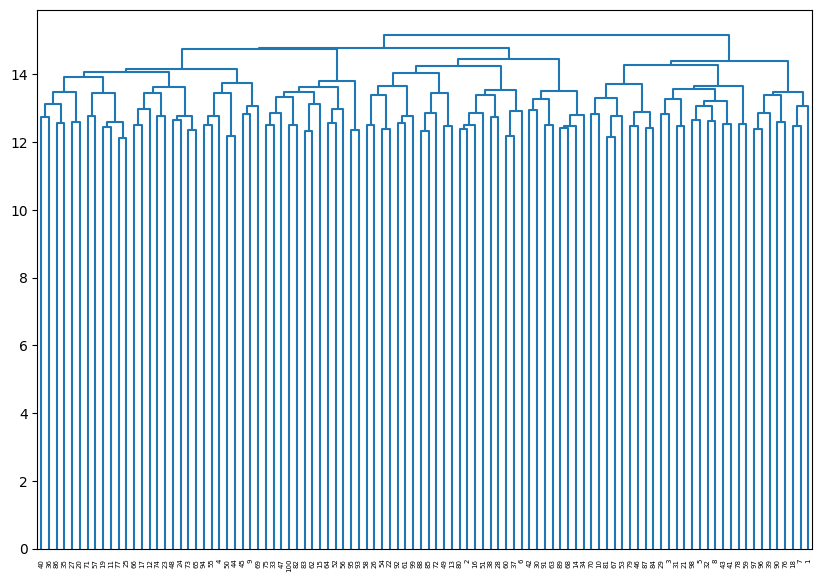

In [109]:
plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=labelList,
            distance_sort='descending',
            show_leaf_counts=True)
plt.show()